<a href="https://colab.research.google.com/github/lanaajs/Processamento-de-Linguagem-Natural-Python/blob/Aulas/02_Aula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import re
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.corpus import stopwords

In [ ]:
nltk.download('stopwords')
stop_words_pt = set(stopwords.words('portuguese'))

pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
corpus = [
    "O dev corrigiu o erro fatal de SQL no banco de dados de produção.",  # Doc 0
    "O sistema apresentou um erro de conexão com o banco de dados.",       # Doc 1
    "O dev alterou a cor primária do botão de login no sistema.",          # Doc 2
    "O botão de login apresentou um erro de renderização na tela.",        # Doc 3
    "A API de pagamentos está falhando ao processar a requisição.",        # Doc 4
    "O banco de dados de pagamentos caiu durante o deploy.",               # Doc 5
    "Nova feature: adicionar botão de compartilhamento na tela principal.",# Doc 6
    "Erro fatal: a API retornou status 500 no ambiente de produção."       # Doc 7
]

In [ ]:
def limpar_texto(texto):
  texto = texto.lower()
  texto = re.sub(r'[^a-záéíóúãõâêîôûç\s]', '', texto)

  palavras = texto.split() #remove espaços vazios
  palavras_limpas = [p for p in palavras if p not in stop_words_pt] # retorna uma lista de palavras muito frequentes em português

  return " ". join(palavras_limpas)

In [ ]:
corpus_limpo = [limpar_texto(doc) for doc in corpus]

In [ ]:
print("CORPUS LIMPO\n")

# ficou as palavras com significados concretos, removeu os artigos...

for i, doc in enumerate(corpus_limpo):
  print(f"Doc {i}: {doc}")

CORPUS LIMPO

Doc 0: dev corrigiu erro fatal sql banco dados produção
Doc 1: sistema apresentou erro conexão banco dados
Doc 2: dev alterou cor primária botão login sistema
Doc 3: botão login apresentou erro renderização tela
Doc 4: api pagamentos falhando processar requisição
Doc 5: banco dados pagamentos caiu durante deploy
Doc 6: nova feature adicionar botão compartilhamento tela principal
Doc 7: erro fatal api retornou status ambiente produção


In [ ]:
# transforma textos em números usando TF-IDF e considerando palavras isoladas e pares de palavras
vectorizer_tfidf = TfidfVectorizer(ngram_range=(1, 2))

In [ ]:
# aprende o vocabulário do corpus e gera a matriz numérica TF-IDF para cada documento
matrix_tfidf = vectorizer_tfidf.fit_transform(corpus_limpo)

# lista de todas as palavras e combinações transformadas
vocabulario = vectorizer_tfidf.get_feature_names_out()

In [ ]:
# calcula o peso total de cada palavra/termo no corpus inteiro e transforma em um vetor plano
pesos_totais = np.asarray(matrix_tfidf.sum(axis=0)).ravel()

# seleciona os índices das 10 palavras/termos mais importantes (maior peso TF-IDF total) no corpus
top_indices = pesos_totais.argsort()[-10:][::-1]

# contém as 10 palavras ou n-gramas mais relevantes do seu corpu
top_palavras = [vocabulario[i] for i in top_indices]

# cria uma lista com os pesos TF-IDF totais correspondentes às 10 palavras/termos mais importantes
top_pesos = [pesos_totais[i] for i in top_indices]

/tmp/ipython-input-383/2171369261.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_pesos, y=top_palavras, palette="viridis")


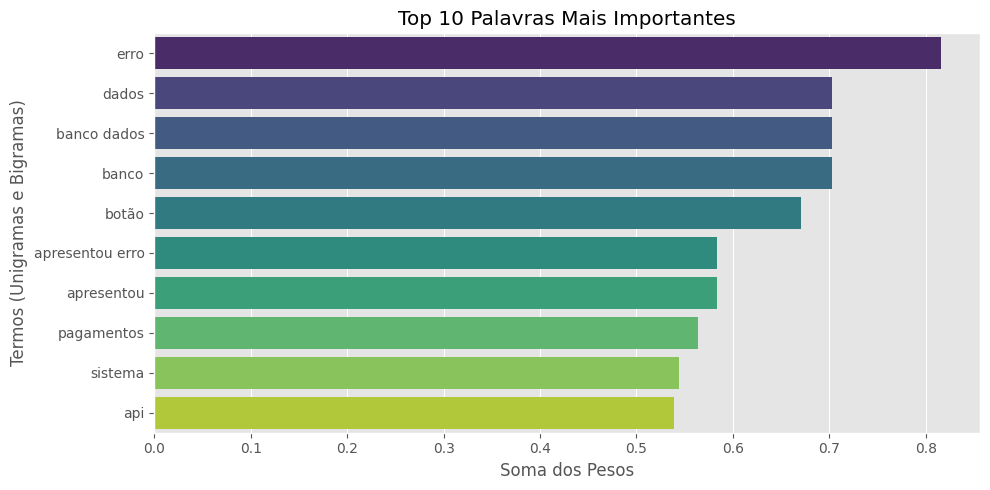

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x=top_pesos, y=top_palavras, palette="viridis")
plt.title("Top 10 Palavras Mais Importantes")
plt.xlabel("Soma dos Pesos")
plt.ylabel("Termos (Unigramas e Bigramas)")
plt.tight_layout()
plt.show()

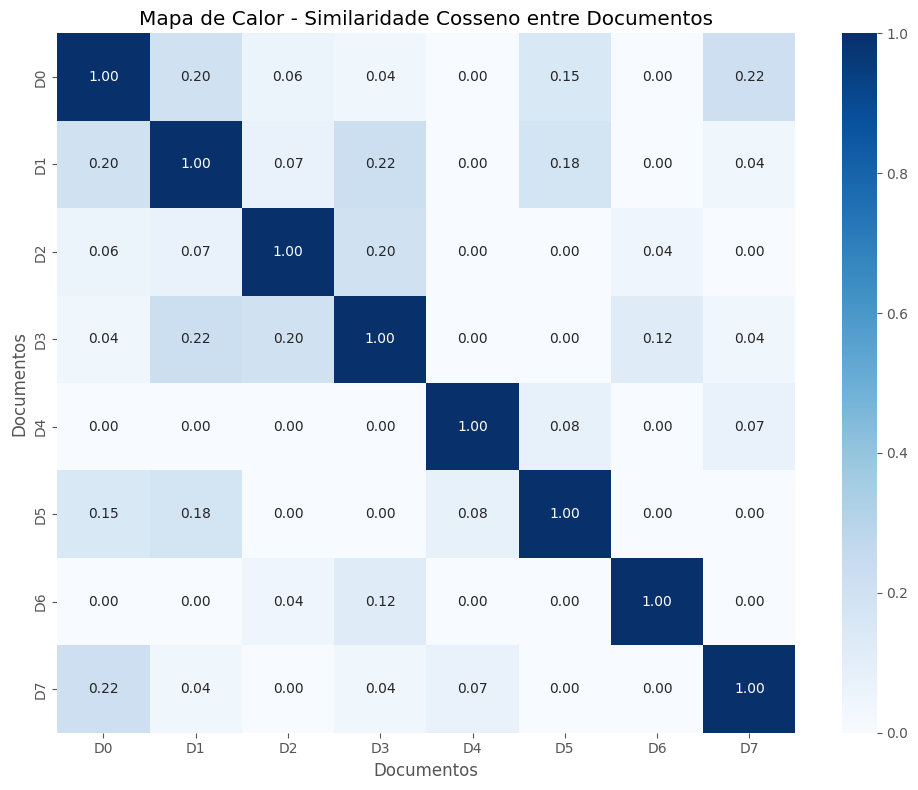

In [ ]:
# calcula a similaridade cosseno entre documentos
similaridade_matriz = cosine_similarity(matrix_tfidf)

# plot do heatmap
plt.figure(figsize=(10,8))
sns.heatmap(similaridade_matriz, annot=True, cmap='Blues', fmt='.2f',
            xticklabels=[f"D{i}" for i in range(similaridade_matriz.shape[0])],
            yticklabels=[f"D{i}" for i in range(similaridade_matriz.shape[0])])

plt.title("Mapa de Calor - Similaridade Cosseno entre Documentos")
plt.xlabel("Documentos")
plt.ylabel("Documentos")
plt.tight_layout()
plt.show()

# Cada célula (i, j) mostra similaridade cosseno entre o documento i e j (0 = nada parecido, 1 = idênticos).
# A diagonal principal sempre é 1, pois cada documento é idêntico a si mesmo.
# A matriz é simétrica, então (i, j) = (j, i).
# Linhas mostram a similaridade do documento com todos os outros; colunas mostram o mesmo.
# No heatmap, cores mais escuras = documentos mais semelhantes; mais claras = menos semelhantes.

In [ ]:
def buscar_issues(query, top_n=3):
    busca_limpa = limpar_texto(query)
    vetor_busca = vectorizer_tfidf.transform([busca_limpa])

    # corrige flatten e usa top_n
    similaridades = cosine_similarity(vetor_busca, matrix_tfidf).flatten()
    indices_top = similaridades.argsort()[-top_n:][::-1]

    print(f"Sua busca: '{query}'\n")
    print("-"*50)

    for rank, idx in enumerate(indices_top):
        score = similaridades[idx]

        if score > 0:
            print(f"Rank {rank + 1} | Similaridade: {score*100:.1f}% | Doc {idx}")
            print(f"Conteúdo: {corpus[idx]}\n")
        else:
            print(f"Rank {rank + 1} | Nenhum documento restante atingiu similaridade")
            break

In [ ]:
buscar_issues("O banco de dados parou de funcionar e deu erro na API")

Sua busca: 'O banco de dados parou de funcionar e deu erro na API'

--------------------------------------------------
Rank 1 | Similaridade: 42.4% | Doc 1
Conteúdo: O sistema apresentou um erro de conexão com o banco de dados.

Rank 2 | Similaridade: 35.1% | Doc 0
Conteúdo: O dev corrigiu o erro fatal de SQL no banco de dados de produção.

Rank 3 | Similaridade: 31.5% | Doc 5
Conteúdo: O banco de dados de pagamentos caiu durante o deploy.

